# Play MASA Safety Gridworlds

Choose an environment with the buttons. The preview cell renders inline with `rgb_array`, and the last cell opens a `pygame` window for keyboard play. Set `RECORD_VIDEO = True` to save the environment canvas as a 1920x1080 MP4.

In [10]:
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
from masa.common.rendering.notebook_play import make_reset_env, sync_selected_env
from masa.common.rendering.notebook_play import start_recorded_play_thread

RECORD_VIDEO = True
VIDEO_PATH = "videos/notebooks/play_safety_gridworlds.mp4"
VALID_ENV_NAMES = ("IslandNavigation", "ConveyorBelt", "Sokoban")

def make_env(env_name, **kwargs):
    if env_name == "IslandNavigation":
        from masa.envs.discrete.island_navigation import IslandNavigation
        return IslandNavigation(**kwargs)
    if env_name == "ConveyorBelt":
        from masa.envs.discrete.conveyor_belt import ConveyorBelt
        return ConveyorBelt(**kwargs)
    if env_name == "Sokoban":
        from masa.envs.discrete.sokoban import Sokoban
        return Sokoban(**kwargs)
    raise ValueError(f"env_name must be one of {VALID_ENV_NAMES!r}")

ENV_SELECTOR = widgets.ToggleButtons(options=VALID_ENV_NAMES, value="Sokoban", description="Env")
display(ENV_SELECTOR)
ENV_NAME = ENV_SELECTOR.value
SEED = 0


ToggleButtons(description='Env', index=2, options=('IslandNavigation', 'ConveyorBelt', 'Sokoban'), value='Soko…

reset info: {'box_wall_penalty': 0}


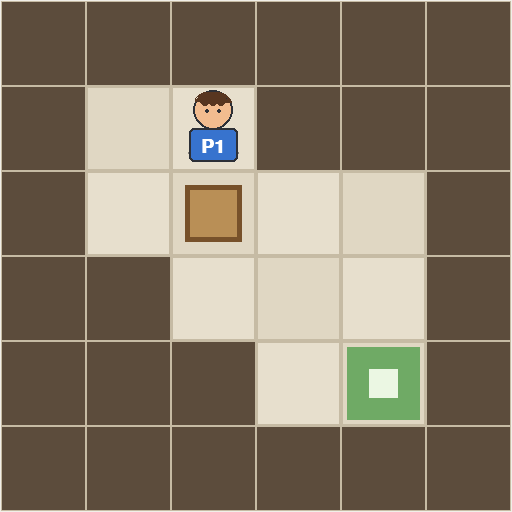

In [11]:
ENV_NAME = ENV_SELECTOR.value
preview_env = make_env(ENV_NAME, render_mode="rgb_array", render_window_size=512)
obs, info = preview_env.reset(seed=SEED)
print("reset info:", info)
display(Image.fromarray(preview_env.render()))
preview_env.close()


In [12]:
def _print_reset_info(info):
    print("reset info:", info)

def play_env(env_name=None, seed: int = 0):
    follow_selector = env_name is None

    def _run(stop_event):
        import pygame
        selected_env_name = env_name
        if follow_selector: selected_env_name = ENV_SELECTOR.value
        action_keys = {pygame.K_RIGHT: 0, pygame.K_UP: 1, pygame.K_LEFT: 2, pygame.K_DOWN: 3, pygame.K_d: 0, pygame.K_w: 1, pygame.K_a: 2, pygame.K_s: 3}
        env, obs, info = make_reset_env(make_env, selected_env_name, seed=seed, render_mode="human", render_window_size=512)
        finished = False
        print("Controls: arrows or WASD move, R resets, Q or Escape quits.")
        _print_reset_info(info)
        try:
            running = True
            while running and not stop_event.is_set():
                if follow_selector:
                    env, selected_env_name, obs, info, switched = sync_selected_env(env, selected_env_name, ENV_SELECTOR, make_env, seed=seed, render_window_size=512, pygame=pygame)
                    if switched:
                        finished = False
                        print("switched:", selected_env_name)
                        _print_reset_info(info)
                action = None
                for event in pygame.event.get():
                    if event.type == pygame.QUIT: running = False; break
                    if event.type != pygame.KEYDOWN: continue
                    if event.key in (pygame.K_q, pygame.K_ESCAPE): running = False; break
                    if event.key == pygame.K_r:
                        obs, info = env.reset(seed=seed); finished = False; _print_reset_info(info); continue
                    if event.key in action_keys and not finished: action = action_keys[event.key]
                if not running or stop_event.is_set(): break
                if action is not None:
                    obs, reward, terminated, truncated, info = env.step(action)
                    finished = terminated or truncated
                    print({"reward": reward, "terminated": terminated, "truncated": truncated, "info": info})
                else:
                    env.render()
                pygame.time.wait(16)
        finally:
            env.close()

    return start_recorded_play_thread("safety_gridworlds", _run, record_video=RECORD_VIDEO, video_path=VIDEO_PATH)

play_session = play_env(seed=SEED)


Controls: arrows or WASD move, R resets, Q or Escape quits.
reset info: {'box_wall_penalty': 0}
